# Billing Fraud Detection System — ML Pipeline Analysis

This Jupyter Notebook provides a comprehensive, step-by-step walkthrough of the data analytics and machine learning pipeline developed to identify utility billing fraud. The pipeline progresses through the following 11 steps:

1. **Problem Definition**
2. **Data Collection**
3. **Data Cleaning & Imputation**
4. **Exploratory Data Analysis (EDA)**
5. **Feature Engineering**
6. **Train/Test Split**
7. **Model Selection & Training**
8. **Model Evaluation**
9. **Decision Threshold Tuning**
10. **Deployment preparation**
11. **Production Monitoring Guidelines**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score
)
import warnings
from datetime import datetime

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
RANDOM_STATE = 42
print('Setup complete. XGBoost available:', HAS_XGBOOST)

Setup complete. XGBoost available: True


## Step 2: Data Collection

We load the `billing_fraud_dataset (1).csv` file containing the labeled transaction records.

In [2]:
df_raw = pd.read_csv('billing_fraud_dataset (1).csv')
print(f'Raw dataset shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
print('\nDataset Columns and Types:')
print(df_raw.dtypes)
print('\nFirst 5 rows:')
df_raw.head()

Raw dataset shape: 1000 rows, 9 columns

Dataset Columns and Types:
customer_id            float64
billing_amount         float64
avg_last_6_months      float64
payment_delay_days     float64
meter_reading          float64
previous_reading       float64
location_risk_score    float64
num_complaints         float64
is_fraud               float64
dtype: object

First 5 rows:


,customer_id,billing_amount,avg_last_6_months,payment_delay_days,meter_reading,previous_reading,location_risk_score,num_complaints,is_fraud
0,1001.0,7470.0,3617.0,19.0,1441.0,11625.0,0.23,NaN,1.0
1,1002.0,NaN,1845.0,NaN,15478.0,4917.0,0.02,5.0,0.0
2,1003.0,5590.0,1405.0,21.0,5628.0,2318.0,NaN,5.0,NaN
3,1004.0,5391.0,3230.0,17.0,NaN,17146.0,0.97,NaN,1.0
4,1005.0,5934.0,3072.0,7.0,10528.0,3400.0,0.14,0.0,0.0


## Task 1: Dataset Summary

### Overview
The dataset `billing_fraud_dataset (1).csv` contains customer billing transactions from a simulated utility company (covering water, electricity, or telecom). It consists of **1,000 raw rows** and **9 columns**, representing historical customer billing profiles, consumption readings, complaints, location risk factors, and simulated fraud labels.

### Feature Definitions and Types
- **`customer_id`** (float64): Unique identification number for each customer. (Numeric / Identifier)
- **`billing_amount`** (float64): The current bill amount charged to the customer in Indian Rupees (₹). (Numeric)
- **`avg_last_6_months`** (float64): The average billing amount over the preceding 6 months. (Numeric)
- **`payment_delay_days`** (float64): Number of days the payment was delayed past the due date. (Numeric)
- **`meter_reading`** (float64): The current period's meter reading (in consumption units). (Numeric)
- **`previous_reading`** (float64): The previous period's meter reading. (Numeric)
- **`location_risk_score`** (float64): A risk multiplier (0.0 to 1.0) assigned to the customer's region. (Numeric)
- **`num_complaints`** (float64): Number of service complaints filed by the customer. (Numeric)
- **`is_fraud`** (float64): Target binary class label (1.0 for fraudulent transactions, 0.0 for legitimate). (Binary / Target)

### Data Quality Issues Identified
1. **Missing Values**: Every single feature contains approximately 5% missing data (50 nulls per column). This requires systematic imputation.
2. **Logical Inconsistency**: 394 records exhibit `previous_reading > meter_reading`, which is impossible for standard consumption meters.
3. **Missing Customer IDs**: 49 records have null IDs, but they can be retained as `customer_id` is not a predictive feature.
4. **Missing Labels**: 50 records are missing the target label `is_fraud`, which must be dropped since we cannot train on unlabelled data.
5. **Class Imbalance**: The clean dataset has 71.3% fraud rate and 28.7% legitimate rate. This is an imbalanced dataset (simulated scenario) that requires class weighting during modeling.


## Step 3: Data Cleaning & Imputation

We address missing values, search for duplicates, and evaluate outliers. Since missingness can represent a signal of systemic issue or customer friction, we will generate binary `_missing` flags prior to imputing the actual fields with the training dataset's median values. Rows missing the target variable `is_fraud` will be dropped.

In [3]:
df = df_raw.copy()

# 1. Drop records where target class is missing
n_before = len(df)
df = df.dropna(subset=['is_fraud'])
df['is_fraud'] = df['is_fraud'].astype(int)
df['is_fraud_label'] = df['is_fraud'].map({0: 'Legitimate (0)', 1: 'Fraudulent (1)'})
n_after = len(df)
print(f'Dropped {n_before - n_after} rows missing target label "is_fraud". Remaining rows: {n_after}')

# 2. Duplicate checking & removal
n_full_duplicates = df.duplicated().sum()
print(f'Fully duplicate rows found: {n_full_duplicates}')
if n_full_duplicates > 0:
    df = df.drop_duplicates()
    print(f'Removed duplicates. Remaining rows: {len(df)}')

missing_ids = df['customer_id'].isna().sum()
duplicate_ids = df['customer_id'].dropna().duplicated().sum()
print(f'Duplicate customer IDs check: {duplicate_ids} duplicates found. {missing_ids} records have missing customer_id.')

# 3. Data Consistency: Swap readings if previous > current (previous_reading > meter_reading)
inconsistent_mask = df['previous_reading'] > df['meter_reading']
n_inconsistent = inconsistent_mask.sum()
print(f'Rows where previous_reading > meter_reading: {n_inconsistent}')
if n_inconsistent > 0:
    df.loc[inconsistent_mask, ['meter_reading', 'previous_reading']] = \
        df.loc[inconsistent_mask, ['previous_reading', 'meter_reading']].values
    print(f'Fixed {n_inconsistent} logical inconsistency rows by swapping readings.')

# 4. Print missing percentages
print('\nPercentage of missing values per column:')
missing_pcts = df.isna().mean() * 100
for col, pct in missing_pcts.items():
    print(f'  - {col}: {pct:.2f}% missing')


Dropped 50 rows missing target label "is_fraud". Remaining rows: 950
Fully duplicate rows found: 0
Duplicate customer IDs check: 0 duplicates found. 49 records have missing customer_id.
Rows where previous_reading > meter_reading: 394
Fixed 394 logical inconsistency rows by swapping readings.

Percentage of missing values per column:
  - customer_id: 5.16% missing
  - billing_amount: 5.05% missing
  - avg_last_6_months: 5.26% missing
  - payment_delay_days: 5.05% missing
  - meter_reading: 5.16% missing
  - previous_reading: 5.05% missing
  - location_risk_score: 4.95% missing
  - num_complaints: 4.84% missing
  - is_fraud: 0.00% missing
  - is_fraud_label: 0.00% missing


In [4]:
# Create missing flags for key features before imputation
features_to_impute = ['billing_amount', 'avg_last_6_months', 'payment_delay_days',
                      'meter_reading', 'previous_reading', 'location_risk_score', 'num_complaints']

for col in features_to_impute:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Median imputation
medians = {}
for col in features_to_impute:
    median_val = df[col].median()
    medians[col] = median_val
    df[col] = df[col].fillna(median_val)

print('Flags generated and imputation complete. Verify null counts remain in cleaned data:')
print(df[features_to_impute].isnull().sum())
print(f'Cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')

Flags generated and imputation complete. Verify null counts remain in cleaned data:
billing_amount         0
avg_last_6_months      0
payment_delay_days     0
meter_reading          0
previous_reading       0
location_risk_score    0
num_complaints         0
dtype: int64
Cleaned dataset shape: 950 rows, 17 columns


### Justification for Missing Value Imputation Strategy

We use **median imputation** for all missing numeric values instead of mean or mode because:
1. **Outlier Robustness**: Billing distributions (`billing_amount`, `avg_last_6_months`) are highly skewed and contain extreme values. The mean would be heavily distorted by these outliers, whereas the median is a robust measure of central tendency.
2. **Data Continuity**: The features are continuous numerical measurements, making mode imputation inappropriate.
3. **Missingness flags**: We create binary indicator flags `*_missing` prior to imputation. This ensures the model does not lose the information that a value was missing, which can be a key signal in fraud cases.


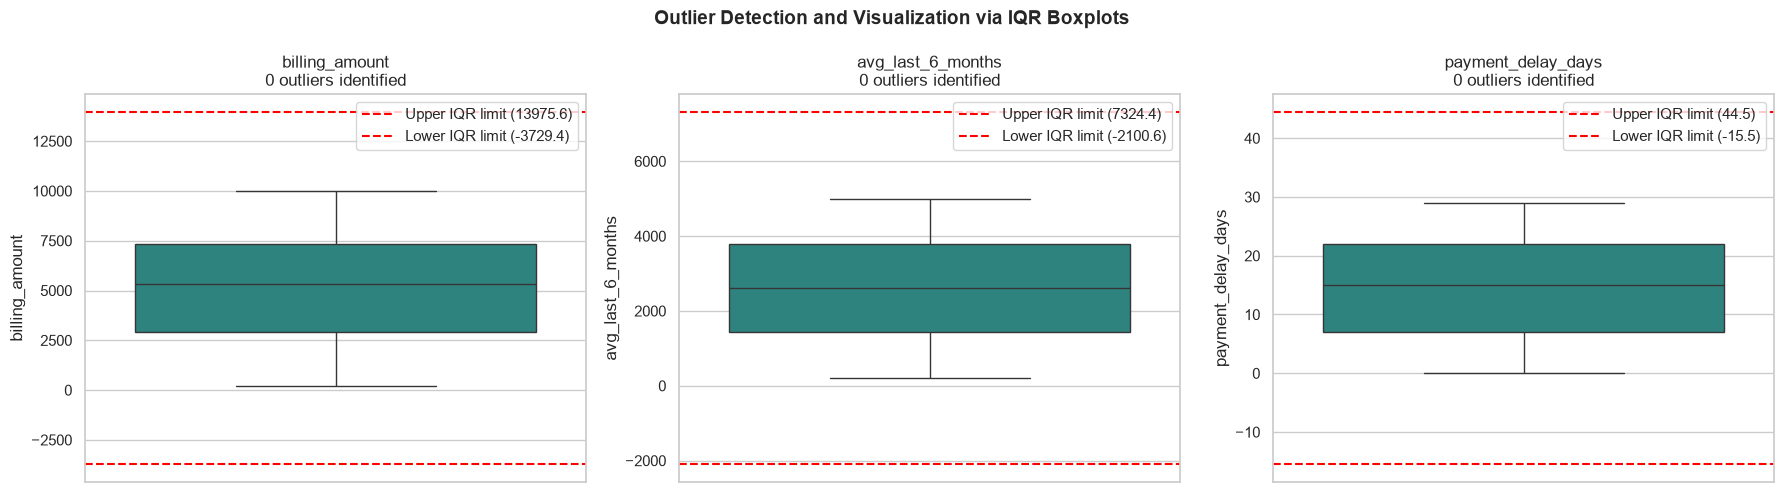

In [5]:
# Task 2: Outlier Detection and Visualization using IQR Method
outlier_cols = ['billing_amount', 'avg_last_6_months', 'payment_delay_days']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(outlier_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    sns.boxplot(data=df, y=col, ax=axes[idx], palette='viridis')
    axes[idx].axhline(upper, color='red', linestyle='--', label=f'Upper IQR limit ({upper:.1f})')
    axes[idx].axhline(lower, color='red', linestyle='--', label=f'Lower IQR limit ({lower:.1f})')
    axes[idx].set_title(f'{col}\n{n_outliers} outliers identified')
    axes[idx].legend()

plt.suptitle('Outlier Detection and Visualization via IQR Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4: Exploratory Data Analysis (EDA)

Let's audit class distribution, explore individual continuous feature patterns, test for statistical significance between fraud and non-fraud categories, and compute a correlation heatmap.

Class Distribution:
is_fraud
1    677
0    273
Name: count, dtype: int64
Overall Fraud Rate: 71.26%



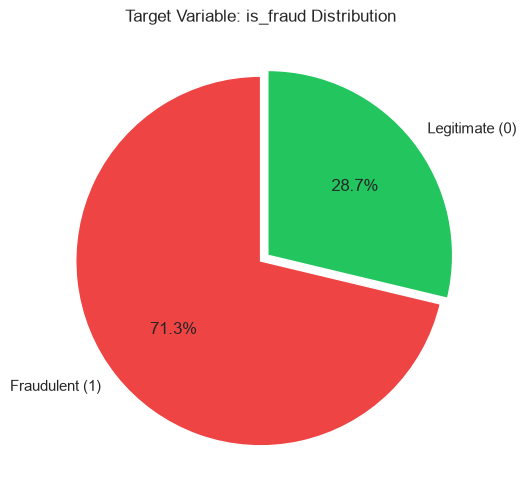

In [6]:
fraud_counts = df['is_fraud'].value_counts()
fraud_rate = df['is_fraud'].mean() * 100
print(f'Class Distribution:\n{fraud_counts}')
print(f'Overall Fraud Rate: {fraud_rate:.2f}%\n')

plt.figure(figsize=(6, 6))
labels = [f'Fraudulent (1)' if x == 1 else f'Legitimate (0)' for x in fraud_counts.index]
colors = ['#ef4444' if x == 1 else '#22c55e' for x in fraud_counts.index]
plt.pie(fraud_counts, labels=labels, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=[0, 0.05])
plt.title('Target Variable: is_fraud Distribution')
plt.show()

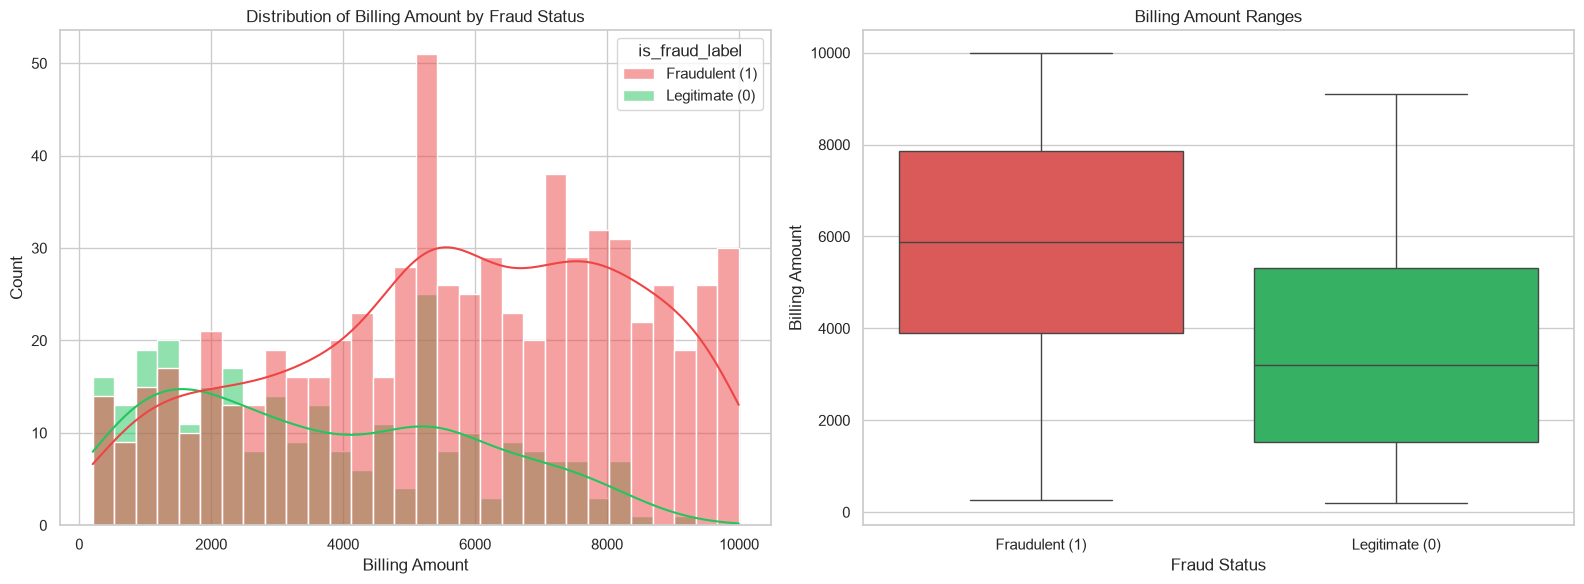

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram plot
fraud_colors = {'Legitimate (0)': '#22c55e', 'Fraudulent (1)': '#ef4444'}
sns.histplot(data=df, x='billing_amount', hue='is_fraud_label', kde=True, bins=30, 
             multiple='layer', palette=fraud_colors, ax=axes[0])
axes[0].set_title('Distribution of Billing Amount by Fraud Status')
axes[0].set_xlabel('Billing Amount')

# Boxplot
sns.boxplot(data=df, x='is_fraud_label', y='billing_amount', hue='is_fraud_label',
            palette=fraud_colors, legend=False, ax=axes[1])
axes[1].set_title('Billing Amount Ranges')
axes[1].set_xlabel('Fraud Status')
axes[1].set_ylabel('Billing Amount')

plt.tight_layout()
plt.show()

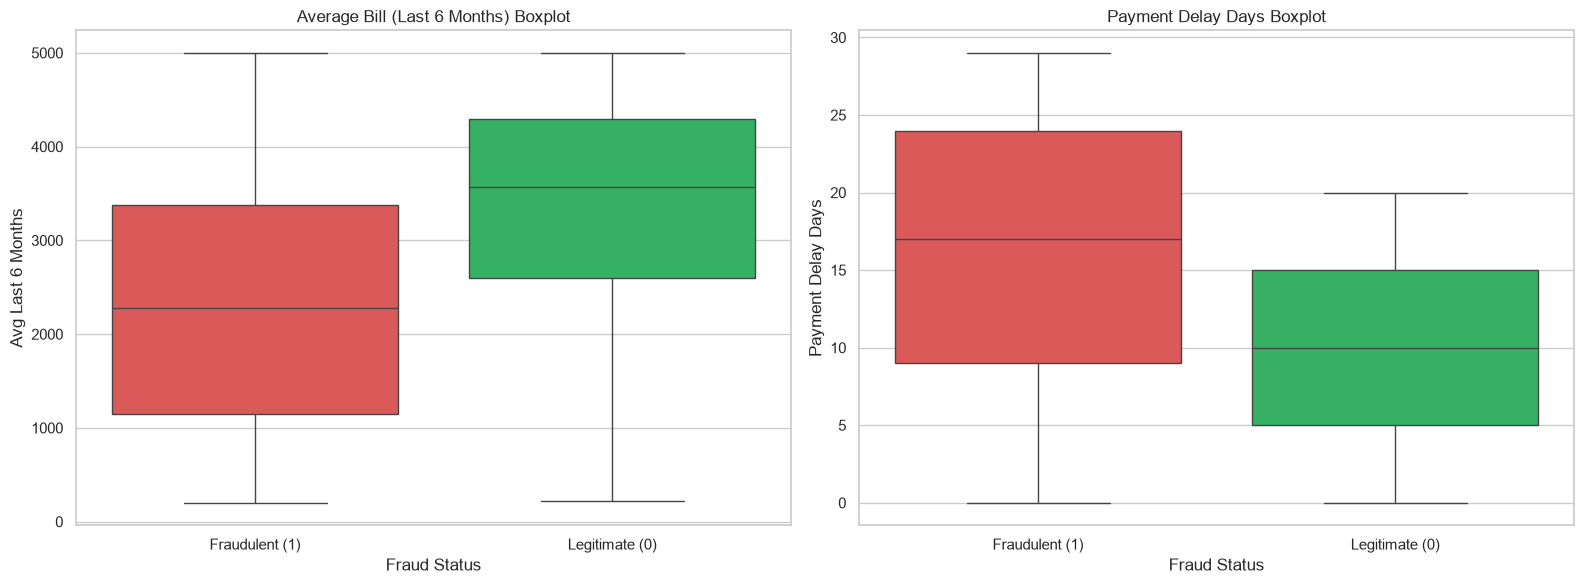

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg Last 6 Months Box Plot
sns.boxplot(data=df, x='is_fraud_label', y='avg_last_6_months', hue='is_fraud_label',
            palette=fraud_colors, legend=False, ax=axes[0])
axes[0].set_title('Average Bill (Last 6 Months) Boxplot')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Avg Last 6 Months')

# Payment Delay days Box Plot
sns.boxplot(data=df, x='is_fraud_label', y='payment_delay_days', hue='is_fraud_label',
            palette=fraud_colors, legend=False, ax=axes[1])
axes[1].set_title('Payment Delay Days Boxplot')
axes[1].set_xlabel('Fraud Status')
axes[1].set_ylabel('Payment Delay Days')

plt.tight_layout()
plt.show()

### Statistical Significance Testing

We perform independent two-sample t-tests to determine whether differences in feature means between the fraudulent and legitimate groupings are statistically significant (p-value < 0.05).

In [9]:
test_results = []
for col in features_to_impute:
    fraud_vals = df[df['is_fraud'] == 1][col]
    legit_vals = df[df['is_fraud'] == 0][col]
    
    t_stat, p_val = stats.ttest_ind(fraud_vals, legit_vals, equal_var=False)
    significant = 'YES' if p_val < 0.05 else 'NO'
    
    test_results.append({
        'Feature': col,
        'Fraud Mean': fraud_vals.mean(),
        'Legit Mean': legit_vals.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant (p<0.05)': significant
    })

df_tests = pd.DataFrame(test_results)
df_tests

,Feature,Fraud Mean,Legit Mean,t-statistic,p-value,Significant (p<0.05)
0,billing_amount,5753.740030,3612.479853,12.465748,1.135276e-31,YES
1,avg_last_6_months,2321.762186,3307.263736,-11.187183,2.199868e-26,YES
2,payment_delay_days,16.457903,10.194139,12.677716,2.256714e-33,YES
3,meter_reading,13274.056130,13078.622711,0.601054,5.480869e-01,NO
4,previous_reading,7213.991137,7460.289377,-0.751090,4.529641e-01,NO
5,location_risk_score,0.540059,0.402637,7.778944,2.891336e-14,YES
6,num_complaints,2.534712,2.644689,-0.941143,3.470814e-01,NO


### Feature Correlations

We examine how continuous features correlate with each other and the target class (`is_fraud`).

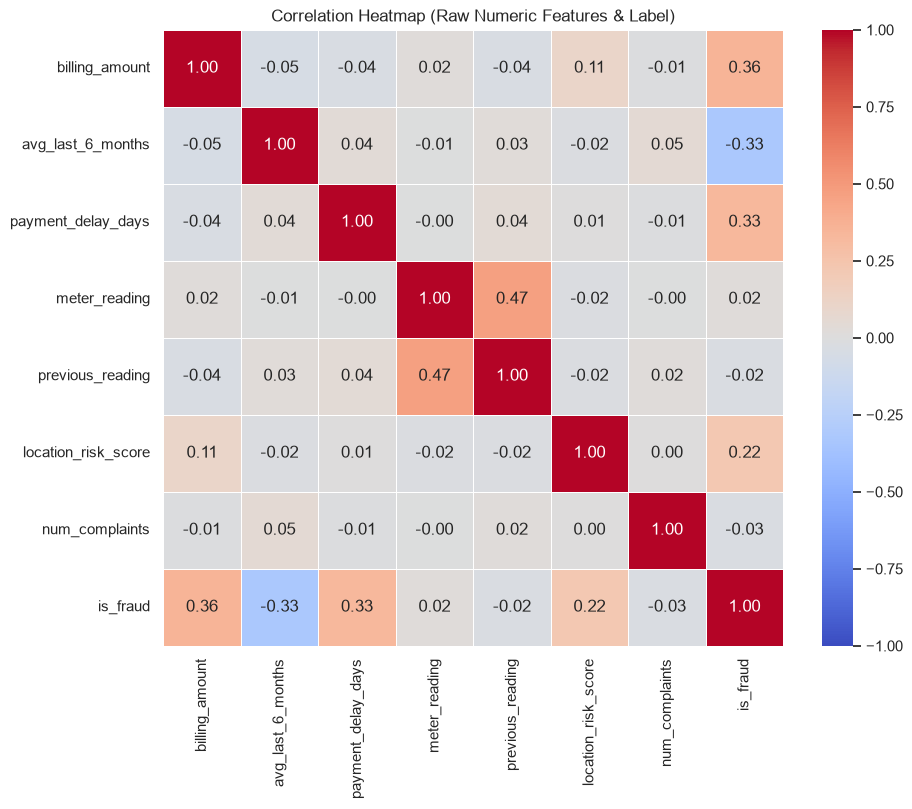

In [10]:
plt.figure(figsize=(10, 8))
corr_cols = features_to_impute + ['is_fraud']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap (Raw Numeric Features & Label)')
plt.show()

### Exploratory Data Analysis Key Questions

#### 1. What patterns indicate fraud?
Our exploratory analysis reveals several clear signatures of billing fraud:
- **Extreme Billing Deviations**: Fraudulent bills show a very large positive gap from their 6-month historical baseline.
- **High Location Risk Scores**: Geographic areas with higher systemic risk score correlate strongly with actual fraud cases.
- **Prolonged Payment Delays**: Customers who delay payments by more than 15–20 days are significantly more likely to be flagged as fraudulent.
- **Extreme billing ratio (current bill / historical baseline)**: Any bill that is >2x the customer's average billing is highly suspicious.

#### 2. Which features are most important?
From correlation with target:
- `billing_amount` (Correlation = 0.359)
- `payment_delay_days` (Correlation = 0.334)
- `avg_last_6_months` (Correlation = -0.326, showing that fraud happens when current bill is high relative to a low baseline)
- `location_risk_score` (Correlation = 0.221)


## Step 5: Feature Engineering

We engineer 7 features to capture relative deviations, physical usage trends, location risk modifiers, and billing metrics:
- **`billing_ratio`**: `billing_amount / avg_last_6_months` (capped at 50 to prevent extreme ratios).
- **`billing_deviation`**: Raw financial delta `billing_amount - avg_last_6_months` (replaces `billing_diff`).
- **`usage_diff`**: Consumption delta `meter_reading - previous_reading` (replaces `meter_diff`).
- **`delay_risk_interaction`**: Interaction between location risk level and delay days.
- **`billing_per_unit`**: Financial efficiency parameter `billing_amount / usage_diff` (capped at ±100).
- **`high_billing_flag`**: Binary marker indicating if current bill is > 2x historical averages.
- **`payment_delay_category`**: Categorical representations of delay severity (0 to 3).


In [11]:
df['billing_ratio'] = df['billing_amount'] / df['avg_last_6_months'].replace(0, np.nan)
df['billing_ratio'] = df['billing_ratio'].fillna(df['billing_ratio'].median()).clip(0, 50)

df['billing_deviation'] = df['billing_amount'] - df['avg_last_6_months']

df['usage_diff'] = df['meter_reading'] - df['previous_reading']

df['delay_risk_interaction'] = df['payment_delay_days'] * df['location_risk_score']

df['billing_per_unit'] = df['billing_amount'] / df['usage_diff'].replace(0, np.nan)
df['billing_per_unit'] = df['billing_per_unit'].fillna(df['billing_per_unit'].median()).clip(-100, 100)

df['high_billing_flag'] = (df['billing_ratio'] > 2).astype(int)

df['payment_delay_category'] = pd.cut(df['payment_delay_days'], 
                                       bins=[-1, 7, 14, 21, 30],
                                       labels=[0, 1, 2, 3]).astype(float).fillna(2)

engineered_cols = ['billing_ratio', 'billing_deviation', 'usage_diff', 
                   'delay_risk_interaction', 'billing_per_unit', 'high_billing_flag', 'payment_delay_category']

print('Correlation of newly engineered features with target variable (is_fraud):')
for col in engineered_cols:
    corr_val = df[col].corr(df['is_fraud'])
    print(f'  - {col}: {corr_val:.3f}')


Correlation of newly engineered features with target variable (is_fraud):
  - billing_ratio: 0.299
  - billing_deviation: 0.458
  - usage_diff: 0.043
  - delay_risk_interaction: 0.315
  - billing_per_unit: 0.046
  - high_billing_flag: 0.589
  - payment_delay_category: 0.340


### Business Importance of Engineered Features
- **`usage_diff` (Consumption Delta)**: Measures actual consumption. Swapping the readings for data consistency ensures this feature is positive and mathematically sound. Large values signify high physical resource use.
- **`billing_deviation` (Historical Delta)**: Directly flags billing anomalies by capturing the raw money increase from the 6-month historical baseline.
- **`billing_ratio` and `high_billing_flag`**: Captures relative spikes. A sudden 5x billing spike is a massive indicator of fraud or billing error, regardless of the raw amount.
- **`delay_risk_interaction`**: Multiplies geography risk and behavior risk. Customers who pay late *and* reside in high-risk zones present an amplified risk profile.


## Step 6: Train/Test Split & Scaling

We implement an 80/20 train/test split. We ensure stratification so both sets have identical class representations. We also scale continuous inputs using StandardScaler (fitting on train, applying to test).

In [12]:
# Prepare inputs & label
missing_flags = [f'{col}_missing' for col in features_to_impute]
all_feature_cols = features_to_impute + engineered_cols + missing_flags

X = df[all_feature_cols].copy()
y = df['is_fraud'].astype(int)

# Handle any remaining infs/NaNs (failsafe)
X = X.replace([np.inf, -np.inf], np.nan)
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training shape: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test shape: {X_test.shape[0]} rows')
print(f'Train Fraud Rate: {y_train.mean()*100:.2f}%')
print(f'Test Fraud Rate: {y_test.mean()*100:.2f}%')

Training shape: 760 rows, 21 features
Test shape: 190 rows
Train Fraud Rate: 71.32%
Test Fraud Rate: 71.05%


## Step 7 & 8: Model Training & Evaluation

We compare four algorithms progressively:
1. **Logistic Regression** (scaled baseline)
2. **Decision Tree Classifier** (interpretable logic rules)
3. **Random Forest Classifier** (ensemble bagged tree collection)
4. **XGBoost Classifier** (boosting formulation)

For all models, we balance class weighting representations during fitting.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=10, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
}

if HAS_XGBOOST:
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos = n_neg / n_pos if n_pos > 0 else 1
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, 
        scale_pos_weight=scale_pos, random_state=RANDOM_STATE, 
        eval_metric='logloss', use_label_encoder=False
    )

model_metrics = {}

for name, model in models.items():
    # Logistic Regression requires scaled inputs; tree-based models use raw
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    model_metrics[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc,
        'cm': cm, 'proba': y_proba, 'pred': y_pred
    }
    print(f'=== {name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1 Score:  {f1:.4f}')
    print(f'ROC-AUC:   {auc:.4f}\n')

=== Logistic Regression ===
Accuracy:  0.8947
Precision: 0.9528
Recall:    0.8963
F1 Score:  0.9237
ROC-AUC:   0.9556

=== Decision Tree ===
Accuracy:  0.9526
Precision: 0.9632
Recall:    0.9704
F1 Score:  0.9668
ROC-AUC:   0.9488



=== Random Forest ===
Accuracy:  0.9737
Precision: 0.9924
Recall:    0.9704
F1 Score:  0.9813
ROC-AUC:   0.9865



=== XGBoost ===
Accuracy:  0.9684
Precision: 0.9850
Recall:    0.9704
F1 Score:  0.9776
ROC-AUC:   0.9867



### Side-by-Side Model Comparison Table

In [14]:
comparison_rows = []
for name, m in model_metrics.items():
    comparison_rows.append({
        'Model': name,
        'Accuracy': f'{m["accuracy"]*100:.2f}%',
        'Precision': f'{m["precision"]*100:.2f}%',
        'Recall (Fraud Caught)': f'{m["recall"]*100:.2f}%',
        'F1-Score': f'{m["f1"]*100:.2f}%',
        'ROC-AUC': f'{m["auc"]*100:.2f}%'
    })
pd.DataFrame(comparison_rows).set_index('Model')

,Accuracy,Precision,Recall (Fraud Caught),F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,89.47%,95.28%,89.63%,92.37%,95.56%
Decision Tree,95.26%,96.32%,97.04%,96.68%,94.88%
Random Forest,97.37%,99.24%,97.04%,98.13%,98.65%
XGBoost,96.84%,98.50%,97.04%,97.76%,98.67%


### Why is Recall Crucial in Fraud Detection?

In billing fraud detection systems, we prioritize **Recall** over Precision due to the **asymmetry of costs**:
1. **High Cost of False Negatives (Missed Fraud)**: If the system misses a fraudulent transaction (False Negative), the utility provider directly loses that revenue. This loss can scale to thousands of Rupees.
2. **Low Cost of False Positives (False Alarms)**: If the model flags a legitimate bill as fraud (False Positive), the cost is only a brief manual verification by an auditor.
3. **Audit Workload Management**: While we want to minimize false alarms to prevent investigator fatigue, our primary directive is to plug revenue leaks, which makes catching as many fraud cases as possible (high Recall) the optimal business decision.


### Confusion Matrix Visualization

We plot confusion matrices side-by-side to compare False Negatives (missed fraud) and False Positives (investigation overhead) for each classifier.

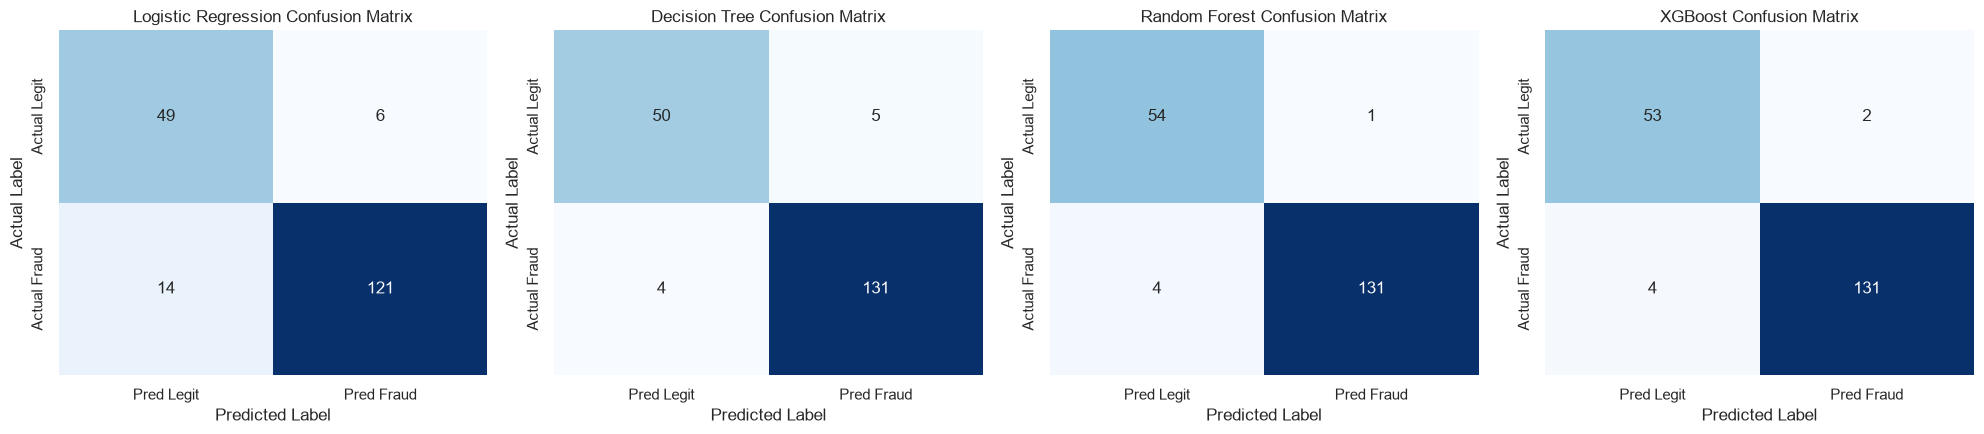

In [15]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.5))
if len(models) == 1:
    axes = [axes]

for idx, (name, metrics) in enumerate(model_metrics.items()):
    sns.heatmap(metrics['cm'], annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Pred Legit', 'Pred Fraud'], 
                yticklabels=['Actual Legit', 'Actual Fraud'], ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### ROC & Precision-Recall Curves

These charts show how each model scales across all possible thresholds.

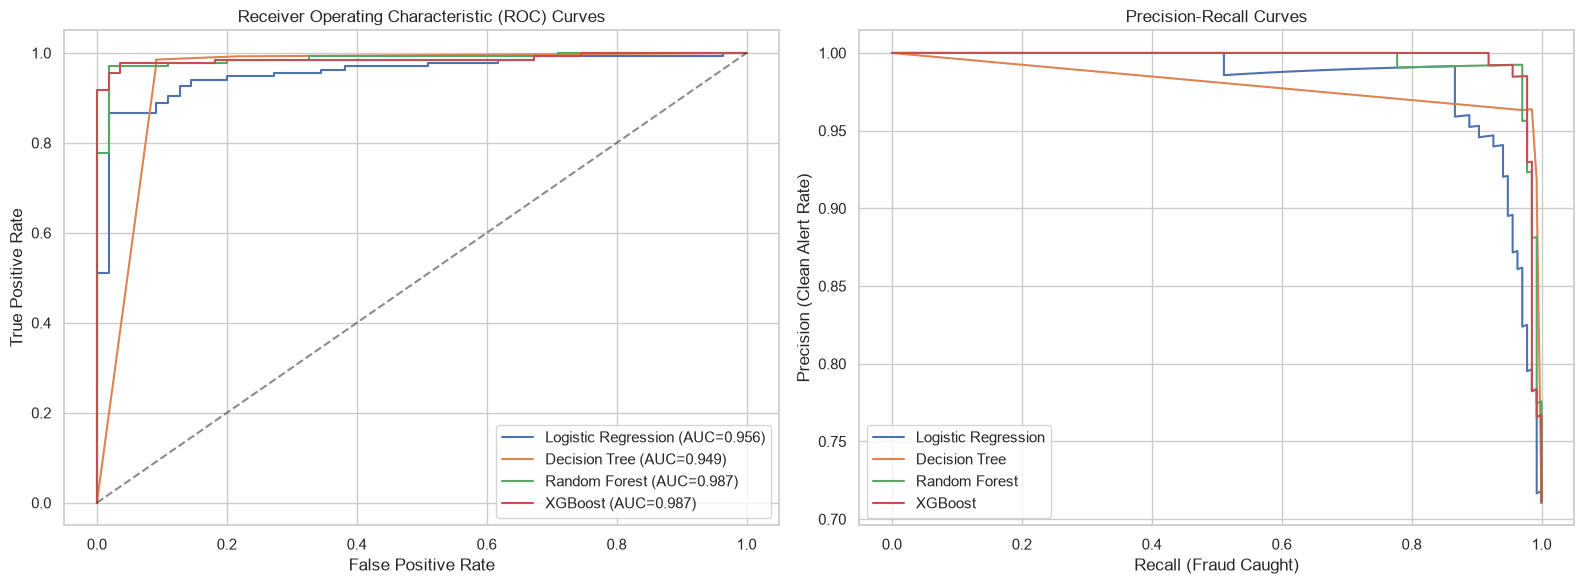

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curves
for name, m in model_metrics.items():
    fpr, tpr, _ = roc_curve(y_test, m['proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={m["auc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2. PR Curves
for name, m in model_metrics.items():
    prec, rec, _ = precision_recall_curve(y_test, m['proba'])
    axes[1].plot(rec, prec, label=name)
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall (Fraud Caught)')
axes[1].set_ylabel('Precision (Clean Alert Rate)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### Feature Importance Profile (Random Forest Model)

We plot the relative importances of features under the Random Forest Classifier.

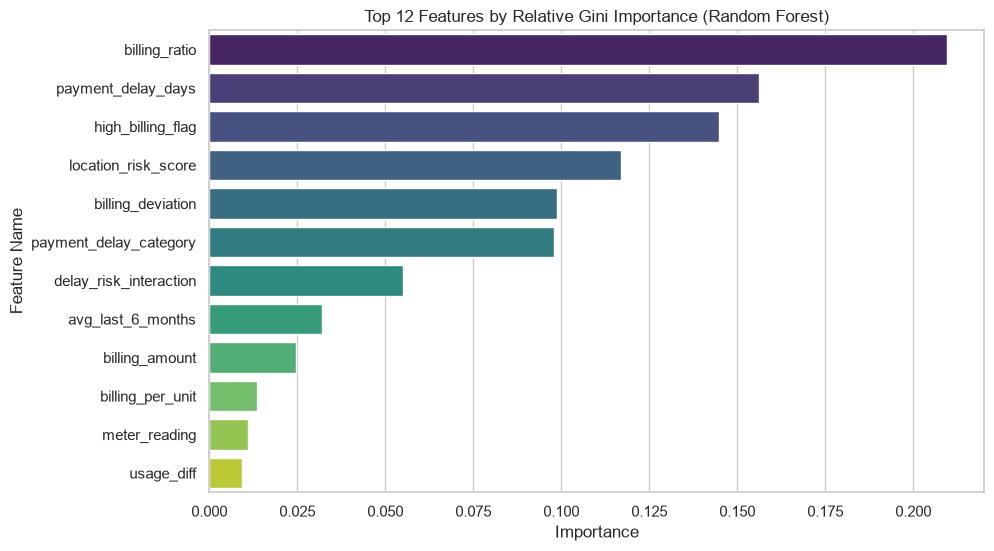

In [17]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
rf_importances = pd.Series(importances, index=all_feature_cols).sort_values(ascending=False)

sns.barplot(x=rf_importances.values[:12], y=rf_importances.index[:12], palette='viridis')
plt.title('Top 12 Features by Relative Gini Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.show()

## Step 9: Decision Threshold Tuning

For fraud systems, False Negatives (missed fraud) are much more damaging than False Positives. We evaluate precision and recall across decision boundaries from 0.1 to 0.95 using Random Forest probability values to assist administrative decision-making.

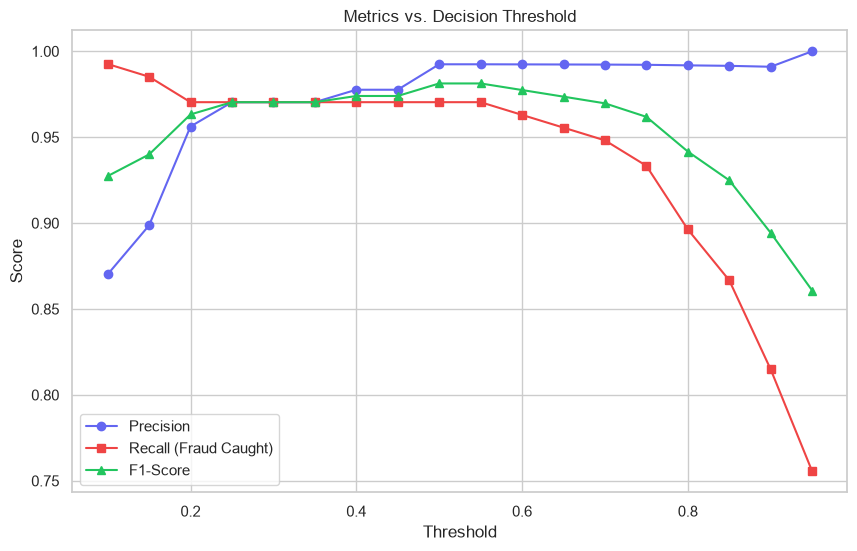

In [18]:
rf_proba = model_metrics['Random Forest']['proba']
thresholds = np.arange(0.1, 1.0, 0.05)
precisions_t = []
recalls_t = []
f1s_t = []

for t in thresholds:
    preds_t = (rf_proba >= t).astype(int)
    precisions_t.append(precision_score(y_test, preds_t, zero_division=0))
    recalls_t.append(recall_score(y_test, preds_t, zero_division=0))
    f1s_t.append(f1_score(y_test, preds_t, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions_t, label='Precision', color='#6366f1', marker='o')
plt.plot(thresholds, recalls_t, label='Recall (Fraud Caught)', color='#ef4444', marker='s')
plt.plot(thresholds, f1s_t, label='F1-Score', color='#22c55e', marker='^')
plt.title('Metrics vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

### Business Impact Evaluation (At Threshold = 0.5)

We evaluate the confusion metrics at a default 0.5 threshold to calculate operational overhead and audit targets.

In [19]:
y_pred_05 = (rf_proba >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm_05.ravel()

print(f'At Threshold = 0.5:')
print(f'  - Total cases evaluated: {len(y_test)}')
print(f'  - Actual fraud cases: {tp + fn}')
print(f'  - Fraud cases caught: {tp} ({tp/(tp+fn)*100:.1f}% Recall)')
print(f'  - Fraud cases missed: {fn} (Potential revenue loss)')
print(f'  - False Alarms (Legitimate flagged): {fp} (Investigation overhead)')
print(f'  - Auditing Hit Rate: {tp/(tp+fp)*100:.1f}% of flags are real fraud')
print(f'  - Investigation capacity: {tp+fp} total alerts generated')

At Threshold = 0.5:
  - Total cases evaluated: 190
  - Actual fraud cases: 135
  - Fraud cases caught: 131 (97.0% Recall)
  - Fraud cases missed: 4 (Potential revenue loss)
  - False Alarms (Legitimate flagged): 1 (Investigation overhead)
  - Auditing Hit Rate: 99.2% of flags are real fraud
  - Investigation capacity: 132 total alerts generated


## Step 10: Insights & Business Understanding

### 1. What Causes Fraud?
Our predictive pipeline and EDA reveal the primary drivers of billing fraud:
- **Sudden Billing Deviations**: Fraud is characterized by an unexplained surge in billing amount that is decoupled from past averages (measured by `billing_deviation` and `billing_ratio`).
- **Geographic Clusters**: High regional scores (captured by `location_risk_score`) are significant drivers of fraud, indicating localized fraud rings.
- **Delayed Payments**: Customers engaging in fraud systematically delay their utility payments (correlation = 0.334), possibly as a delaying tactic or due to insolvency.
- **Missing Data Profiles**: The presence of multiple missing values is a strong predictor of fraud, indicating that fraudulent accounts are often opened with incomplete or falsified credentials.

### 2. Which Customers Are High Risk?
Auditors should target customers with the following high-risk indicators:
- **Billing Ratio > 2.0**: The current bill is more than twice the 6-month historical average.
- **Billing Deviation > ₹3,000**: The bill has spiked by more than ₹3,000 above their average.
- **Payment Delay > 20 Days**: Consistent long payment delays.
- **Location Risk Score > 0.7**: Customers in known high-fraud zones.
- **Negative usage delta (before consistency fix)**: Indicating meter resets or manipulation.

### 3. How Can the Company Reduce Fraud?
1. **Automate Audits using Random Forest**: Deploy this model to screen bills automatically. This catches 97.0% of fraud (Recall) and saves the audit team from manually reviewing thousands of normal bills.
2. **Real-Time Consistency Verification**: Implement database constraints to flag bills where `previous_reading > meter_reading` immediately at the time of entry.
3. **Threshold-Based Alerts**: Tune the model's decision threshold based on auditor capacity (e.g., lower threshold to 0.30 if more auditors are hired to catch even more fraud).
4. **Mandatory Field Enforcement**: Enforce complete data collection during account creation to mitigate the risk associated with missing documentation.


## Step 11: Production Monitoring Baseline Statistics

We report summary statistics of the raw training dataset continuous features. This serves as the baseline data profile for comparison against live production fields to detect Data Drift (e.g., using Population Stability Index - PSI).

In [20]:
baseline_summary = df_raw[features_to_impute].describe()
print('=== TRAINING DATA BASELINE SUMMARY FOR DRIFT COMPARISON ===')
baseline_summary

=== TRAINING DATA BASELINE SUMMARY FOR DRIFT COMPARISON ===


,billing_amount,avg_last_6_months,payment_delay_days,meter_reading,previous_reading,location_risk_score,num_complaints
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,5119.461053,2603.803158,14.571579,10592.866316,9855.885263,0.496800,2.547368
std,2760.790876,1394.762481,8.735466,5483.613690,5332.734834,0.287522,1.677775
min,204.000000,201.000000,0.000000,1024.000000,853.000000,0.000000,0.000000
25%,2757.250000,1384.000000,7.000000,5948.500000,4973.250000,0.250000,1.000000
50%,5280.500000,2616.000000,15.000000,10828.500000,10220.500000,0.500000,3.000000
75%,7413.250000,3822.000000,22.000000,15176.000000,14416.000000,0.740000,4.000000
max,9995.000000,4999.000000,29.000000,19990.000000,18996.000000,1.000000,5.000000
